# German Credit Dataset — Multicollinearity Check

Checks multicollinearity among numeric features using a correlation heatmap and Variance Inflation Factor (VIF).

Guidelines often used in practice:
- VIF > 5: potentially problematic multicollinearity
- VIF > 10: strong multicollinearity

---
## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from IPython.display import display
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})

print('Libraries loaded.')

Libraries loaded.


---
## 2. Load Data

In [2]:
ARFF_PATH = '../data/raw/dataset_31_credit-g.arff'
raw_data, meta = arff.loadarff(ARFF_PATH)
df = pd.DataFrame(raw_data)

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].apply(lambda x: x.decode('utf-8') if isinstance(x, (bytes, bytearray)) else x)

print(f'Loaded: {ARFF_PATH}  |  shape: {df.shape}')
df.head()

Loaded: ../data/raw/dataset_31_credit-g.arff  |  shape: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


---
## 3. Select Numeric Features

This analysis focuses on numeric features only. Categorical features are excluded because correlation and VIF depend on numeric encoding choices.

In [3]:
target_col = 'class' if 'class' in df.columns else df.columns[-1]
X = df.drop(columns=[target_col])
num_X = X.select_dtypes(include='number').copy()

print('Target column:', target_col)
print('Numeric features:', list(num_X.columns))
print('Shape (numeric only):', num_X.shape)

num_X = num_X.dropna()
print('Shape after dropping missing rows:', num_X.shape)

Target column: class
Numeric features: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Shape (numeric only): (1000, 7)
Shape after dropping missing rows: (1000, 7)


---
## 4. Correlation Matrix

Top absolute correlations (excluding self-correlation):


duration                credit_amount             0.624984
credit_amount           installment_commitment    0.271316
residence_since         age                       0.266419
age                     existing_credits          0.149254
                        num_dependents            0.118201
existing_credits        num_dependents            0.109667
residence_since         existing_credits          0.089625
duration                installment_commitment    0.074749
installment_commitment  num_dependents            0.071207
                        age                       0.058266
                        residence_since           0.049302
residence_since         num_dependents            0.042643
duration                age                       0.036136
                        residence_since           0.034067
credit_amount           age                       0.032716
dtype: float64

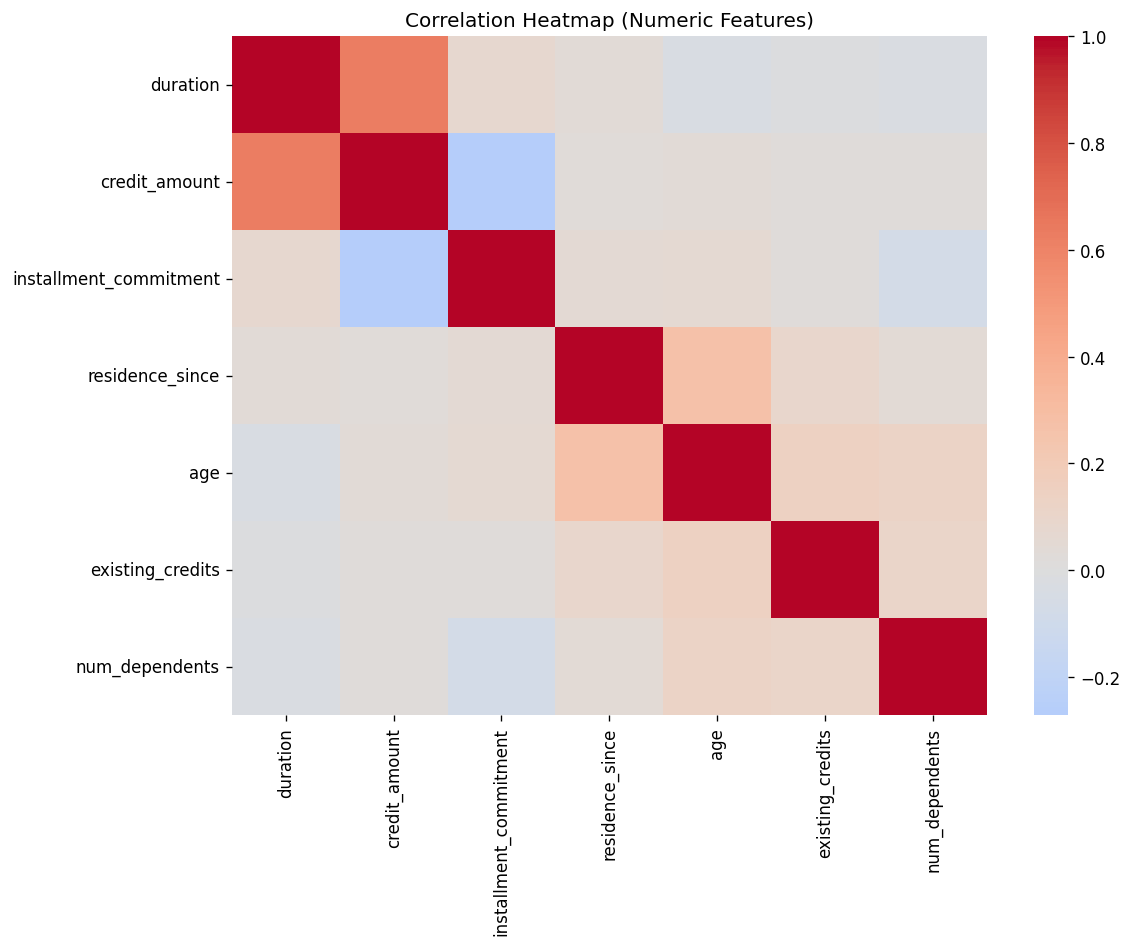

In [4]:
if num_X.shape[1] < 2:
    print('Not enough numeric features to compute correlations.')
else:
    corr = num_X.corr()
    corr_abs = corr.abs()
    upper_mask = np.triu(np.ones(corr_abs.shape, dtype=bool), k=1)
    top_pairs = corr_abs.where(upper_mask).stack().sort_values(ascending=False)

    print('Top absolute correlations (excluding self-correlation):')
    display(top_pairs.head(15))

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
    plt.title('Correlation Heatmap (Numeric Features)')
    plt.tight_layout()
    plt.show()

---
## 5. Variance Inflation Factor (VIF)

In [5]:
if num_X.shape[1] < 2:
    print('Not enough numeric features to compute VIF.')
else:
    constant_cols = [c for c in num_X.columns if num_X[c].nunique() <= 1]
    num_X_vif = num_X.drop(columns=constant_cols) if constant_cols else num_X

    if constant_cols:
        print('Removed constant columns:', constant_cols)

    if num_X_vif.shape[1] < 2:
        print('Not enough remaining numeric features to compute VIF after removing constant columns.')
    else:
        vif_df = pd.DataFrame({
            'feature': num_X_vif.columns,
            'VIF': [variance_inflation_factor(num_X_vif.values, i) for i in range(num_X_vif.shape[1])]
        }).sort_values('VIF', ascending=False)

        print('VIF results (higher = more multicollinearity):')
        display(vif_df)

        print('Features with VIF > 5:')
        display(vif_df[vif_df['VIF'] > 5])

        print('Features with VIF > 10:')
        display(vif_df[vif_df['VIF'] > 10])

VIF results (higher = more multicollinearity):


,feature,VIF
4,age,10.925702
6,num_dependents,8.790639
2,installment_commitment,7.958660
3,residence_since,7.735368
0,duration,7.358755
5,existing_credits,6.679317
1,credit_amount,4.575758


Features with VIF > 5:


,feature,VIF
4,age,10.925702
6,num_dependents,8.790639
2,installment_commitment,7.958660
3,residence_since,7.735368
0,duration,7.358755
5,existing_credits,6.679317


Features with VIF > 10:


,feature,VIF
4,age,10.925702
